<a href="https://colab.research.google.com/github/fabioaugustopereira/BI/blob/main/AVALIACAO_01/questao_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aluno: Fábio Agusto Pereira - 934



In [1]:
# Import all the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import math
import random
import pandas as pd
from google.colab import files
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import LeavePOut
import pandas as pd
import timeit
import os

In [2]:
# Always reset the pseudo-random numbers generator to a known value so that your results are always the same.
seed = 1234
np.random.seed(seed)

sem escalonamento

In [3]:
def calculateErrorSurface(x1, x2, y):
    """Generate data points for plotting the error surface."""
    # Number of examples.
    N = len(y)
    # Generate values for parameter space.
    M = 1000
    a1 = np.linspace(-10.0, 14.0, M)
    a2 = np.linspace(-10.0, 14.0, M)

    A1, A2 = np.meshgrid(a1, a2)

    # Generate points for plotting the cost-function surface.
    J = np.zeros((M,M))
    for iter1 in range(0, M):
        for iter2 in range(0, M):
            # Hypothesis function.
            yhat = A1[iter1, iter2]*x1 + A2[iter1, iter2]*x2 # Aqui muda se mudar a função objetivo.
            J[iter1, iter2] = (1.0/N)*np.sum(np.square(y - yhat))

    return J, A1, A2

def batchGradientDescent(X, y, alpha=0.4, n_iterations=1000):
    """Batch gradient descent solution."""

    # Retrieve number of examples.
    N = len(y)
    y = y.reshape(N,1)
    # Random initialization of parameters.
    a = np.array([-10.0, -10.0]).reshape(2, 1)

    # Create vector for parameter history.
    a_hist = np.zeros((2, n_iterations+1))
    # Initialize history vector.
    a_hist[:, 0] = a.reshape(2,)

    # Create array for storing error values.
    Jgd = np.zeros(n_iterations+1)

    # Initial error.
    Jgd[0] = (1.0/N)*np.sum(np.power(y - X.dot(a), 2))

    # Batch gradient-descent loop.
    iteration = 0
    error = 1
    grad_hist = np.zeros((2, n_iterations))
    while iteration < n_iterations and error > 0.00001:
        # Gradient.
        gradient = -(2.0/N)*X.T.dot(y - X.dot(a))
        # Update.
        a = a - alpha*gradient

        # MSE.
        Jgd[iteration+1] = (1.0/N)*np.sum(np.power((y - X.dot(a)), 2))

        # History.
        grad_hist[:, iteration] = gradient.reshape(2,)
        a_hist[:, iteration+1] = a.reshape(2,)

        # Error.
        error = np.abs(Jgd[iteration+1] - Jgd[iteration])

        # Increment iteration number.
        iteration = iteration + 1

    return a, Jgd, a_hist, grad_hist, iteration

In [4]:
# Number of pairs feature/label.
N = 1000

x1 = np.random.uniform(100,500,N)
x2 = np.random.uniform(0,1,N)

# Target function.
y = -3*x1 + 2*x2

# Noise.
w = np.random.normal(0,1,N)

# Noisy version.
y_noisy = y + w

# Concatenate both column vectors to create the attribute matrix.
X = np.c_[x1, x2]

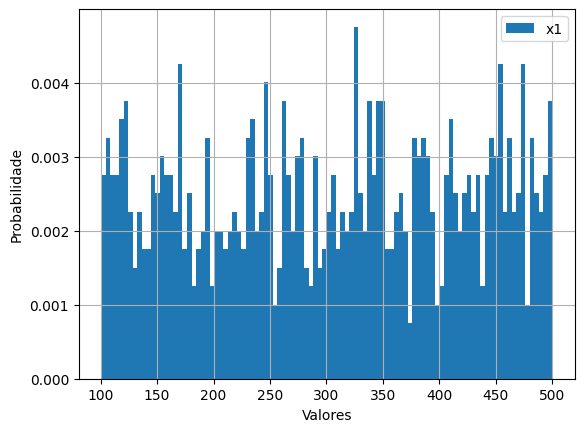

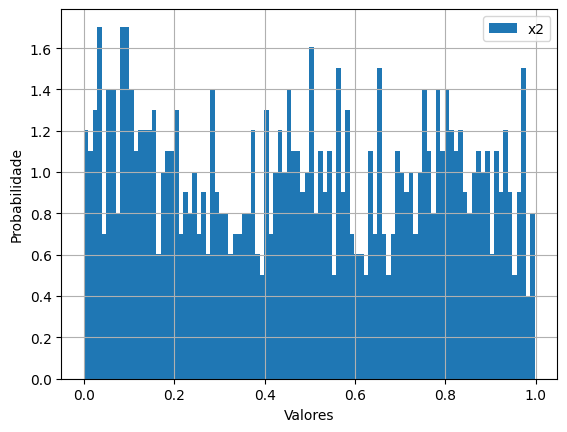

In [5]:
plt.hist(x1, bins=100, density=True, label='x1')
plt.xlabel('Valores')
plt.ylabel('Probabilidade')
plt.legend()
plt.grid()
plt.show()

plt.hist(x2, bins=100, density=True, label='x2')
plt.xlabel('Valores')
plt.ylabel('Probabilidade')
plt.legend()
plt.grid()
plt.show()

In [6]:
def calculateClosedFormSolution(X, y):
    """Calculate closed-form solution using the normal equation."""
    # Number of examples.
    N = len(y)
    # Closed-form solution.
    a_opt = np.linalg.pinv(np.transpose(X).dot(X)).dot(np.transpose(X).dot(y))
    yhat = X.dot(a_opt)
    Joptimum = (1.0/N)*np.sum(np.power((y - yhat), 2))

    return Joptimum, a_opt

# Calculate closed-form solution.
Joptimum, a_opt = calculateClosedFormSolution(X, y_noisy)

# Print best solution.
print('a0: %1.4f' % (a_opt[0]))
print('a1: %1.4f' % (a_opt[1]))
print('Erro ótimo:', Joptimum)

a0: -2.9999
a1: 2.1270
Erro ótimo: 0.9613986436511036


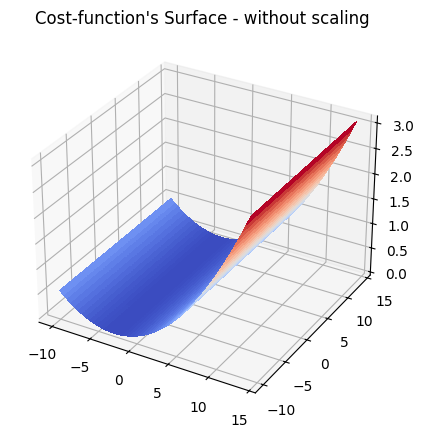

In [7]:
# Calculate data point for plotting error surface.
J, A1, A2 = calculateErrorSurface(x1, x2, y_noisy)

# Plot cost-function surface.
fig = plt.figure(figsize=(18, 5))

ax = plt.subplot(1, 2, 1, projection='3d')
ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('', fontsize=14)
ax.set_ylabel('', fontsize=14)
ax.set_zlabel('', fontsize=14)
plt.title('Cost-function\'s Surface - without scaling')
#Show the plot.
plt.show()

In [8]:
# learning rate.
alpha = 0.0000002 # maximum value before diverging.

# Maximum number of iterations.
n_iterations = 1000

a, Jgd, a_hist, grad_hist, iteration = batchGradientDescent(X, y_noisy, alpha, n_iterations)

print('a1 gd:', a[0])
print('a2 gd:', a[1])

a1 gd: [-2.98326711]
a2 gd: [-9.99017478]


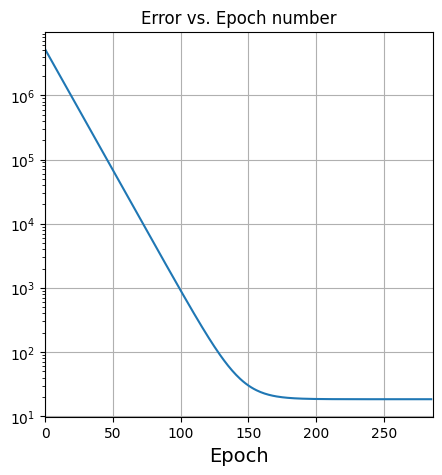

In [9]:
fig = plt.figure(figsize=(5,5))
plt.plot(np.arange(0, iteration), Jgd[0:iteration])
plt.xlim((0, iteration))
plt.yscale('log')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('', fontsize=14)
plt.title('Error vs. Epoch number')
plt.grid()
plt.show()

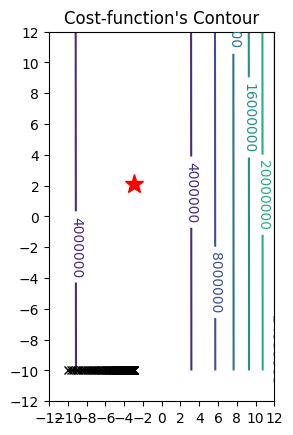

In [10]:
ax = plt.subplot(1, 2, 2)
cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14)
plt.plot(a_hist[0, 0:iteration], a_hist[1, 0:iteration], 'kx')
plt.xlabel('', fontsize=14)
plt.ylabel('', fontsize=14)
plt.title('Cost-function\'s Contour')
ax.set_xticks(np.arange(-12, 14, step=2.0))
ax.set_yticks(np.arange(-12, 14, step=2.0))
plt.xlim([-12,12])
plt.ylim([-12,12])

#Show the plot.
plt.show()

escalonando

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_noisy, test_size=0.2, random_state=seed)

In [12]:
# Import Class StandardScaler from module Preprocessing of
# library sklearn responsible for standardizing the data.
from sklearn.preprocessing import StandardScaler

# Instantiate a Standard scaler.
stdScaler = StandardScaler()

# Standardize the features.
scaled_X_train = stdScaler.fit_transform(X_train)
scaled_X_test = stdScaler.transform(X_test)

# Splitting the attributes.
scaled_x1 = scaled_X_train[:,0].reshape(len(y_train),1)
scaled_x2 = scaled_X_train[:,1].reshape(len(y_train),1)

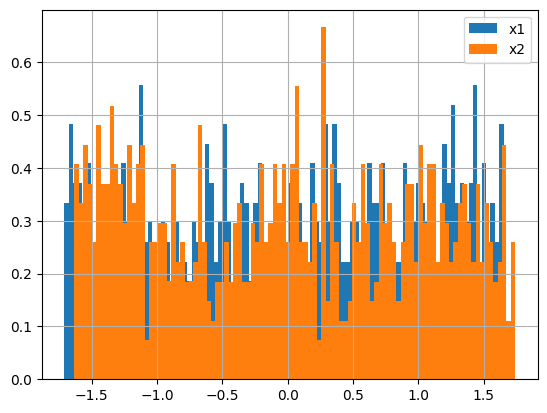

In [13]:
plt.hist(scaled_x1, bins=100, density=True, label='x1')
plt.hist(scaled_x2, bins=100, density=True, label='x2')
plt.legend()
plt.grid()
plt.show()

In [14]:
def calculateClosedFormSolution1(X, y):
    """Calculate closed-form solution using the normal equation."""
    # Number of examples.
    N = len(y)
    # Closed-form solution.
    a_opt = np.linalg.pinv(np.transpose(X).dot(X)).dot(np.transpose(X).dot(y))
    yhat = X.dot(a_opt)
    Joptimum = (1.0/N)*np.sum(np.power((y - yhat), 2))

    return Joptimum, a_opt

# Calculate closed-form solution.
Joptimum, a_opt = calculateClosedFormSolution1(scaled_X_train, y_train)

# Print best solution.
print('a0: %1.4f' % (a_opt[0]))
print('a1: %1.4f' % (a_opt[1]))
print('Erro ótimo:', Joptimum)

a0: -355.8712
a1: 0.6516
Erro ótimo: 828564.6264767731


In [21]:
# learning rate.
alpha = 0.3

# Maximum number of iterations.
n_iterations = 1000

a, Jgd, a_hist, grad_hist, iteration = batchGradientDescent(scaled_X_train, y_train, alpha, n_iterations)

print('a1 gd:', a[0,0])
print('a2 gd:', a[1,0])

a1 gd: -355.87029123107965
a2 gd: 0.6518805356709916


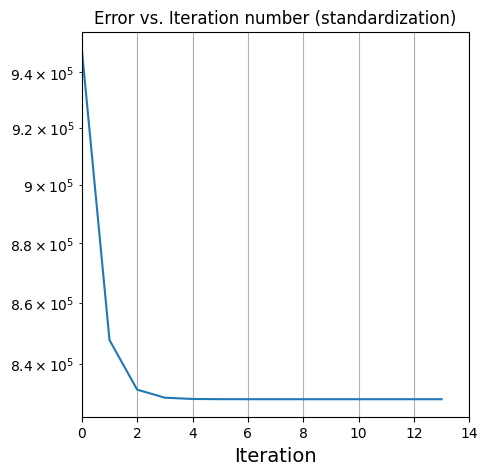

In [22]:
fig = plt.figure(figsize=(5,5))
plt.plot(np.arange(0, iteration), Jgd[0:iteration])
plt.xlim((0, iteration))
plt.yscale('log')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('', fontsize=14)
plt.title('Error vs. Iteration number (standardization)')
plt.grid()
plt.show()

In [ ]:
# Calculate data point for plotting error surface.
J, A1, A2 = calculateErrorSurface(scaled_x1, scaled_x2, y_train)

# Plot cost-function surface.
fig = plt.figure(figsize=(20, 7))

ax = plt.subplot(1, 2, 1, projection='3d')
ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('', fontsize=14)
ax.set_ylabel('', fontsize=14)
ax.set_zlabel('', fontsize=14)
plt.title('Cost-function\'s Surface - with standardization')

ax = plt.subplot(1, 2, 2)
cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14)
plt.plot(a_hist[0, 0:iteration], a_hist[1, 0:iteration], 'kx')
plt.xlabel('', fontsize=14)
plt.ylabel('', fontsize=14)
plt.title('Cost-function\'s Contour')
#plt.ylim([-19.0, 30.0])
#plt.xlim([200, 300])

#Show the plot.
plt.show()

In [ ]:
# Import Class MinMaxScaler from module Preprocessing of library sklearn responsible for normalizing the data.
from sklearn.preprocessing import MinMaxScaler

# Instantiate a MinMax scaler.
minMaxScaler = MinMaxScaler(feature_range=(-0.5, 0.5))

# Standardize the features.
scaled_X_train = minMaxScaler.fit_transform(X_train)
scaled_X_test = minMaxScaler.transform(X_test)

# Splitting the attributes.
scaled_x1 = scaled_X_train[:,0].reshape(len(y_train),1)
scaled_x2 = scaled_X_train[:,1].reshape(len(y_train),1)

In [ ]:
plt.hist(scaled_x1, bins=100, density=True, label='x1')
plt.hist(scaled_x2, bins=100, density=True, label='x2')
plt.legend()
plt.grid()
plt.show()

normalizando

In [ ]:
# Closed-form solution.
a_opt_norm = np.linalg.pinv(np.transpose(scaled_X_train).dot(scaled_X_train)).dot(np.transpose(scaled_X_train).dot(y_train))

print('a1 opt:', a_opt_norm[0,0])
print('a2 opt:', a_opt_norm[1,0])

In [ ]:
# learning rate.
alpha = 0.01 # maximum value before diverging.

# Maximum number of iterations.
n_iterations = 10000

a, Jgd, a_hist, grad_hist, iteration = batchGradientDescent(scaled_X_train, y_train, alpha, n_iterations)

print('a1 gd:', a[0,0])
print('a2 gd:', a[1,0])

In [ ]:
fig = plt.figure(figsize=(5,5))
plt.plot(np.arange(0, iteration), Jgd[0:iteration])
plt.xlim((0, iteration))
plt.yscale('log')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('', fontsize=14)
plt.title('Error vs. Iteration number (normalization)')
plt.grid()
plt.show()

In [ ]:
# Calculate data point for plotting error surface.
J, A1, A2 = calculateErrorSurface(scaled_x1, scaled_x2, y_train)

# Plot cost-function surface.
fig = plt.figure(figsize=(15, 5))

ax = plt.subplot(1, 2, 1, projection='3d')
ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('', fontsize=14)
ax.set_ylabel('', fontsize=14)
ax.set_zlabel('', fontsize=14)
plt.title('Cost-function\'s Surface - with min-max scaling')

ax = plt.subplot(1, 2, 2)
cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.plot(a_opt_norm[0], a_opt_norm[1], c='r', marker='*', markersize=14)
plt.plot(a_hist[0, 0:iteration], a_hist[1, 0:iteration], 'kx')
plt.xlabel('', fontsize=14)
plt.ylabel('', fontsize=14)
plt.title('Cost-function\'s Contour')
#plt.ylim([40.0, 90.0])
#plt.xlim([0.0, 40.0])

#Show the plot.
plt.show()